# Import Modules

In [ ]:
# Common packages
import numpy as np
from collections import defaultdict
import time
from datetime import timedelta
import matplotlib.pyplot as plt

# File management packages
from google.colab import drive
from pathlib import Path
import json
import pickle

# Installation required packages
try:
    import lizard
    import humanize
except ModuleNotFoundError:
    !pip install lizard
    !pip install humanize
    import lizard
    import humanize

# Load Files

In [ ]:
drive.mount('/content/drive')

REPO_PATH = Path("/content/drive/MyDrive/W&M/GenAI/Assignment_1/dataset/ngram_dataset")
TRAIN_FNAME = "train.txt"
VAL_FNAME = "val.txt"
TEST_FNAME = "test.txt"

def count_newline_delimited(file_path):
    count = 0
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():  # ignore empty lines
                count += 1
    return count

print("Counting newline-delimited functions:\n")

files = [TRAIN_FNAME, VAL_FNAME, TEST_FNAME]
for fname in files:
    path = REPO_PATH / fname
    if not path.exists():
        print(f"{fname}: missing")
        continue
    print(f"{fname}: {count_newline_delimited(path)} functions")


Mounted at /content/drive
Counting newline-delimited functions:

train.txt: 75499 functions
val.txt: 1000 functions
test.txt: 1000 functions


# Read files into sequential token Corpus Dictionaries

In [ ]:
# Define max instances for each training set
T1_MAXSIZE = 15000
T2_MAXSIZE = 25000
T3_MAXSIZE = 35000

# Read tokenized files into a corpus array
def construct_corpus(file_path):
    corpus = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            corpus.append(line.split())
    return corpus

# Read training, validation, and testing data into Python
train_corpus = construct_corpus(REPO_PATH / TRAIN_FNAME)
val_corpus = construct_corpus(REPO_PATH / VAL_FNAME)
test_corpus = construct_corpus(REPO_PATH / TEST_FNAME)

# Split training data into three different training sets
# TODO -- investigate corpus type, right now each instance is its own array [[public, int, ...], [private, static, ...]]
train_size = len(train_corpus)
total = T1_MAXSIZE + T2_MAXSIZE + T3_MAXSIZE
if train_size >= total:
    train1_n, train2_n, train3_n = T1_MAXSIZE, T2_MAXSIZE, T3_MAXSIZE
else:
    train1_n = int(train_size * T1_MAXSIZE / total)
    train2_n = int(train_size * T2_MAXSIZE / total)
    train3_n = train_size - train1_n - train2_n

train1_corpus = train_corpus[:train1_n]
train2_corpus = train_corpus[train1_n:train1_n + train2_n]
train3_corpus = train_corpus[train1_n + train2_n:train1_n + train2_n + train3_n]

# Probability Functions

- This is the core of the n-gram model

- Scan a context window of size 'n' over the corpus to count occurrences of certain token orderings

- Add-alpha smoothing to prevent 0 probabilities

In [ ]:
def count_ngram(corpus, ngram):
    """Count occurrences of ngram within corpus"""
    n = len(ngram)
    count = 0
    for i in range(len(corpus) - n + 1):
        if corpus[i:i+n] == ngram:
            count += 1
    return count

def predProbability(ground_truth, context, corpus, vocab, alpha=0.1):
    """Calculate probability of word appearing given context of previous words"""
    tn_count = count_ngram(corpus, context + [ground_truth])
    context_count = count_ngram(corpus, context)

    # Add-alpha smoothing prevents 0 probability
    p = (tn_count + alpha) / (context_count + alpha*len(vocab))
    return p

# Save Probabilities into Model

- Compute probabilities across entire corpus

In [ ]:
class model():
    def __init__(self, corpus, n=3, alpha=0.1):
        self.corpus = corpus
        self.n = n
        self.alpha = alpha
        self.vocab = set(token for sample in corpus for token in sample)

        self.probs = self.build_probs(corpus, n)

    def build_probs(self, corpus, n=3):
        probs = {}

        # Define dictionaries as integer
        context_counts = defaultdict(int)
        ngram_counts = defaultdict(int)

        # Count occurrences of ngram within corpus (similar to bucket sort)
        for sample in corpus:
            if len(sample) < n: # Skip too-small samples
                continue
            for i in range(n-1, len(sample)):
                context = tuple(sample[i-n+1:i])
                word = sample[i]

                context_counts[context] += 1
                ngram_counts[(context, word)] += 1

        # Calculate probability of word appearing given context of previous words
        for (context, word), tn_count in ngram_counts.items():
            context_count = context_counts[context]

            p = (tn_count + self.alpha) / (context_count + self.alpha * len(self.vocab))

            if context not in probs:
                probs[context] = {}

            # Add word to possible outcomes given context
            probs[context][word] = p

        return probs


    def predict(self, context):
        """Greedy Prediction that always chooses the highest probability word"""
        context = tuple(context)

        if context not in self.probs:
            return None, 0.0  # unseen context

        word_probs = self.probs[context]

        best_word = max(word_probs, key=word_probs.get)
        best_prob = word_probs[best_word]

        return best_word, best_prob

    def perplexity(self, corpus,):
        """Compute perplexity treating each sample independently"""

        n = self.n
        log_prob_sum = 0.0
        total_tokens = 0

        for sample in corpus:
            # Skip samples smaller than context window
            if len(sample) < n:
                continue

            # Scan context window over corpus
            for i in range(n-1, len(sample)):
                context = tuple(sample[i-n+1:i])
                word = sample[i]

                # Unseen event
                if context not in self.probs or word not in self.probs[context]:
                    p = 1 / len(self.vocab)  # uniform fallback
                else:
                    p = self.probs[context][word]

                # Protect against log(0)=undefined error
                if p <= 0:
                    return float("inf")

                log_prob_sum += np.log(p)
                total_tokens += 1

        return np.exp(-log_prob_sum / total_tokens)



# Create the Models (one per training set)

In [ ]:
def train_model(name, constructor, *args, save=False, **kwargs):
    # Contstruct model and present time elapsed report
    print(f'Modelling for "{name}"...')
    start = time.time()
    model = constructor(*args, **kwargs)
    elapsed = time.time() - start
    print(f"Model for \"{name}\" finished training in {humanize.precisedelta(elapsed)}.")

    # Save model as pickle file
    if save:
        save_path = REPO_PATH / name
        with open(save_path, "wb") as f:
            pickle.dump(model, f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"{name} saved to {save_path}")

    print("\n\n")
    return model

n = 3
model1 = train_model("model1", model, train1_corpus, n, save=True)
model2 = train_model("model2", model, train2_corpus, n, save=True)
model3 = train_model("model3", model, train3_corpus, n, save=True)

Modelling for "model1"...
Model for "model1" finished training in 2.47 seconds.
model1 saved to /content/drive/MyDrive/W&M/GenAI/Assignment_1/dataset/ngram_dataset/model1



Modelling for "model2"...
Model for "model2" finished training in 4.25 seconds.
model2 saved to /content/drive/MyDrive/W&M/GenAI/Assignment_1/dataset/ngram_dataset/model2



Modelling for "model3"...
Model for "model3" finished training in 5.93 seconds.
model3 saved to /content/drive/MyDrive/W&M/GenAI/Assignment_1/dataset/ngram_dataset/model3





# Load pickle files

- Reloads saved python model object for starting new runtime sessions

In [ ]:
with open(REPO_PATH / "model1", "rb") as f:
    model1 = pickle.load(f)
with open(REPO_PATH / "model2", "rb") as f:
    model2 = pickle.load(f)
with open(REPO_PATH / "model3", "rb") as f:
    model3 = pickle.load(f)

# Evaluate models on validation set

- Calculate perplexity of each of the models trained on different sample sizes to tune the 'n' hyperparameter

- Hypothesis: larger corpuses allow for larger 'n' values but require expenentially more training samples

- Results: n=3 produces the best compromise with minimizing perplexity while still utilizing context

In [ ]:
# Create Perplexities Dictionary (only once)
if "perplexities" not in globals():
    perplexities = {
        "model1": [],
        "model2": [],
        "model3": [],
    }

# Save perplexities
perplexities["model1"].append((n, model1.perplexity(val_corpus)))
perplexities["model2"].append((n, model2.perplexity(val_corpus)))
perplexities["model3"].append((n, model3.perplexity(val_corpus)))

# Print report for given 'n'
print("="*10 + f"  Perplexities for {n=}  " + "="*10)
print("Model 1 Perplexity:",
      next((p for nn, p in perplexities["model1"] if nn == n), None))
print("Model 2 Perplexity:",
      next((p for nn, p in perplexities["model2"] if nn == n), None))
print("Model 3 Perplexity:",
      next((p for nn, p in perplexities["model3"] if nn == n), None))

==========  Perplexities for n=7  ==========
Model 1 Perplexity: 34523.785135351354
Model 2 Perplexity: 40973.28237123642
Model 3 Perplexity: 46038.87540608852


# Plot Perplexity vs 'n'

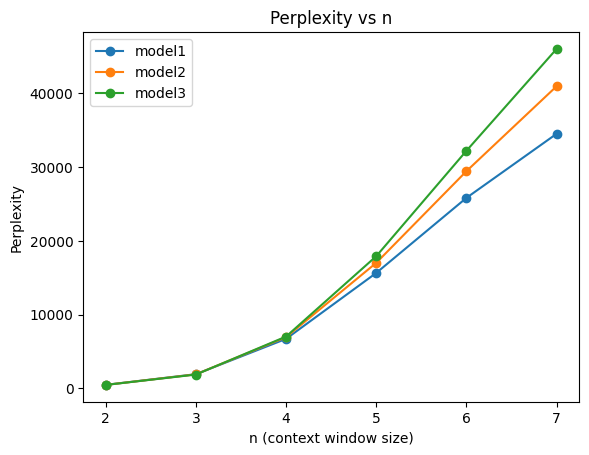

In [ ]:
plt.figure()

for model_name in ["model1", "model2", "model3"]:
    data = sorted(perplexities[model_name], key=lambda x: x[0])  # sort by n
    n_vals = [x[0] for x in data]
    ppl_vals = [x[1] for x in data]

    plt.plot(n_vals, ppl_vals, marker='o', label=model_name)

plt.xlabel("n (context window size)")
plt.ylabel("Perplexity")
plt.title("Perplexity vs n")
plt.legend()

plt.show()


## Save Metadata

- Run over provided test set (results-xxxxxx.json) and my test set (results-yyyyyy.json)

Example Output:

output = {
    "testSet": "test.txt",
    "perplexity": 4.39,
    "data": [
        {
            "index": "ID1",
            "tokenizedCode": "public void run ( ) { }",
            "contextWindow": 3,
            "predictions": [
                {
                    "context": ["public", "void"],
                    "predToken": "run",
                    "predProbability": 0.72,
                    "groundTruth": "run"
                },
                {
                    "context": ["void", "run"],
                    "predToken": "(",
                    "predProbability": 0.85,
                    "groundTruth": "("
                }
            ]
        }
    ]
}

In [ ]:
def build_output(test_fname, corpus, model, alpha=0.1):
    vocab = model.vocab
    n = model.n
    test_path = REPO_PATH / TEST_FNAME

    data_entries = []
    with open(test_path, "r") as f:
        lines = f.readlines()

    for idx, line in enumerate(lines, start=1):
        tokens = line.strip().split()
        predictions = []

        for i in range(n-1, len(tokens)):
            ground_truth = tokens[i]
            context = tokens[i-n+1:i]
            predToken, predProb = model.predict(context)

            predictions.append({
                "context": context,
                "predToken": predToken,
                "predProbability": round(predProb, 3),
                "groundTruth": ground_truth
            })

        data_entries.append({
            "index": f"ID{idx}",
            "tokenizedCode": line.strip(),
            "contextWindow": n,
            "predictions": predictions
        })

    output = {
        "testSet": str(test_fname),
        "perplexity": model.perplexity(corpus),
        "data": data_entries
    }

    return output

# Provided test set
test_fname = "provided_test_set.txt"
out_fname = "results-xxxxxx.json"
# My test set
# test_fname = TEST_FNAME
# out_fname = "results-yyyyyy.json"

# Write to json
output = build_output(test_fname, test_corpus, model3)
output_path = REPO_PATH / Path(out_fname)
with open(str(output_path), "w") as f:
    json.dump(output, f, indent=4)
